# Reference
- https://github.com/MyoHub/myosuite/blob/main/docs/source/tutorials/6_Inverse_Dynamics.ipynb

# Common Libraries

In [2]:
import os, osqp, mujoco
import skvideo.io
import numpy as np
import pandas as pd
from tqdm import tqdm
from copy import deepcopy
import scipy.sparse as spa
from base64 import b64encode
import matplotlib.pyplot as plt
from IPython.display import HTML
from myosuite.simhive.myo_sim.test_sims import TestSims as loader

MyoSuite:> Registering Myo Envs


/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoSarcArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoFatiArmReachFixed-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/seojin/anaconda3/envs/DP/lib/python3.10/site-packages/gymnasium/envs/registration.py:694: UserWarning: WARN: Overriding environment myoArmReachRandom-v0 already in registry.
  logger.warn(f"Overriding environment {new_spe

In [3]:
def show_video(video_path, video_width = 400):
    """
    Display a video within the notebook.
    """
    video_file = open(video_path, "r+b").read()
    video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
    return HTML(f"""<video autoplay width={video_width} controls><source src="{video_url}"></video>""")

def solve_qp(P, q, lb, ub, x0):
    """
    Solve a quadratic program.
    """
    P = spa.csc_matrix(P)
    A = spa.csc_matrix(spa.eye(q.shape[0]))
    m = osqp.OSQP()
    m.setup(P=P, q=q, A=A, l=lb, u=ub, verbose=False)
    m.warm_start(x=x0)
    res = m.solve()
    return res.x

def plot_qxxx(qxxx, joint_names, labels):
    """
    Plot generalized variables to be compared.
    qxxx[:,0,-1] = time axis
    qxxx[:,1:,n] = n-th sequence
    qxxx[:,1:,-1] = reference sequence
    """
    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    axs = axs.flatten()
    line_objects = []
    linestyle = ['-'] * qxxx.shape[2]
    linestyle[-1] = '--'
    for j in range(1, len(joint_names)+1):
        ax = axs[j-1]
        for i in range(qxxx.shape[2]):
            line, = ax.plot(qxxx[:, 0, -1], qxxx[:, j, i], linestyle[i])
            if j == 1: # add only one set of lines to the legend
                line_objects.append(line)
        ax.set_xlim([qxxx[:, 0].min(), qxxx[:, 0].max()])
        ax.set_ylim([qxxx[:, 1:, :].min(), qxxx[:, 1:, :].max()])
        ax.set_title(joint_names[j-1])
    legend_ax = axs[len(joint_names)] # create legend in the 24th subplot area
    legend_ax.axis('off')
    legend_ax.legend(line_objects, labels, loc='center')
    plt.tight_layout()
    plt.show()

def plot_uxxx(uxxx, muscle_names, labels):
    """
    Plot actuator variables to be compared.
    uxxx[:,0,-1] = time axis
    uxxx[:,1:,n] = n-th sequence
    """
    fig, axs = plt.subplots(5, 8, figsize=(12, 8))
    axs = axs.flatten()
    line_objects = []
    for j in range(1, len(muscle_names)+1):
        ax = axs[j-1]
        for i in range(uxxx.shape[2]):
            line, = ax.plot(uxxx[:, 0, -1], uxxx[:, j, i])
            if j == 1: # add only one set of lines to the legend
                line_objects.append(line)
        ax.set_xlim([uxxx[:, 0].min(), uxxx[:, 0].max()])
        ax.set_ylim([uxxx[:, 1:, :].min(), uxxx[:, 1:, :].max()])
        ax.set_title(muscle_names[j-1])
    legend_ax = axs[len(muscle_names)] # create legend in the 40th subplot area
    legend_ax.axis('off')
    legend_ax.legend(line_objects, labels, loc='center')
    plt.tight_layout()
    plt.show()


# Load data

In [22]:
dir_path = "/home/seojin/StudyForMyoSuite/Data"
traj_path = os.path.join(dir_path, "6_trajectory.csv")
traj = pd.read_csv(traj_path).values

In [23]:
def get_qfrc(model, data, target_qpos):
    """
    Compute the generalized force needed to reach the target position in the next mujoco step.
    """
    data_copy = deepcopy(data)
    data_copy.qacc = (((target_qpos - data.qpos) / model.opt.timestep) - data.qvel) / model.opt.timestep
    model.opt.disableflags += mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    mujoco.mj_inverse(model, data_copy)
    model.opt.disableflags -= mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    return data_copy.qfrc_inverse


100%|██████████| 4751/4751 [03:22<00:00, 23.48it/s]


error max (rad): 6.294121305375811e-06


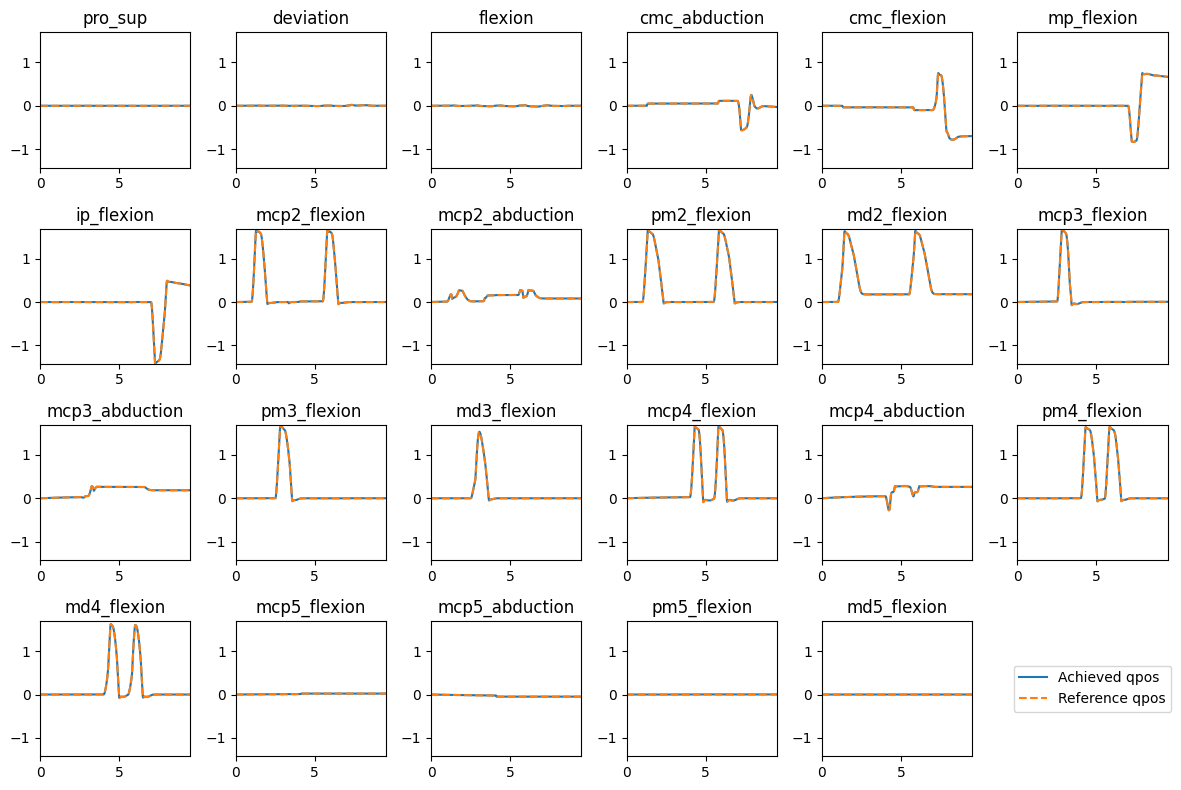

In [24]:
model0 = loader.get_sim(None, 'hand/myohand.xml')
data0 = mujoco.MjData(model0)
qpos_eval = np.zeros((traj.shape[0], traj.shape[1], 2))
qpos_eval[:,:,-1] = traj
for idx in tqdm(range(traj.shape[0])):
    target_qpos = traj[idx, 1:]
    qfrc = get_qfrc(model0, data0, target_qpos)
    data0.qfrc_applied = qfrc
    mujoco.mj_step(model0, data0)
    qpos_eval[idx,:,0] = np.hstack((data0.time, data0.qpos))
error = ((qpos_eval[:,1:,0] - qpos_eval[:,1:,-1])**2).mean(axis=0)
print(f'error max (rad): {error.max()}')
joint_names = [model0.joint(i).name for i in range(model0.nq)]
plot_qxxx(qpos_eval, joint_names, ['Achieved qpos', 'Reference qpos'])
